Using device: cpu
Размер датасета: 4320 строк
Диапазон дат: 2025-01-01 00:00:00 до 2025-06-29 23:00:00

Пропуски в данных:
date      0
target    0
dtype: int64


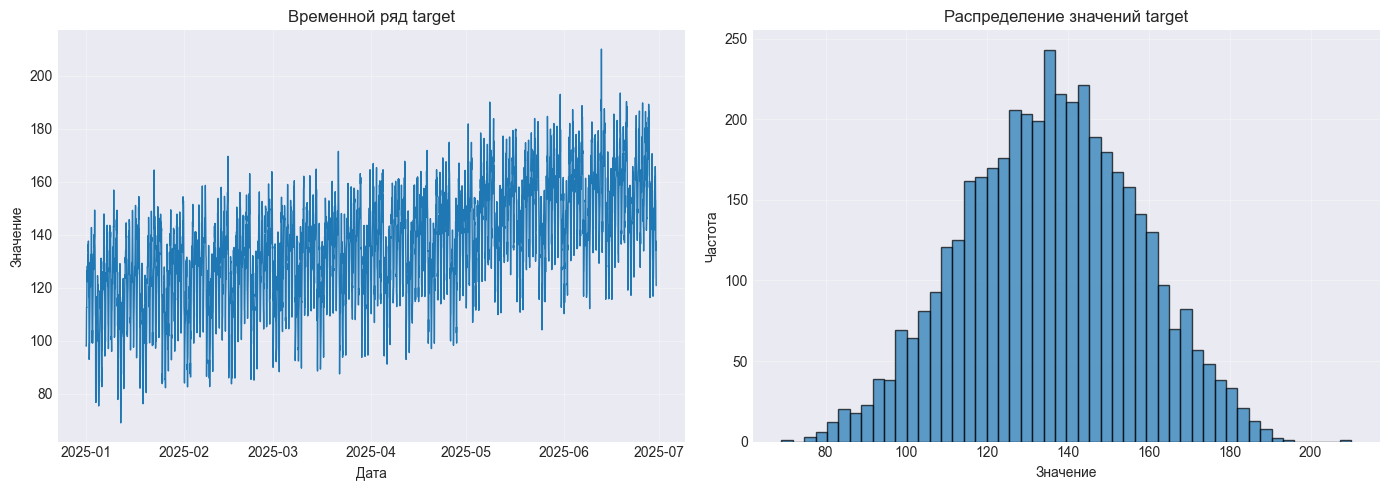

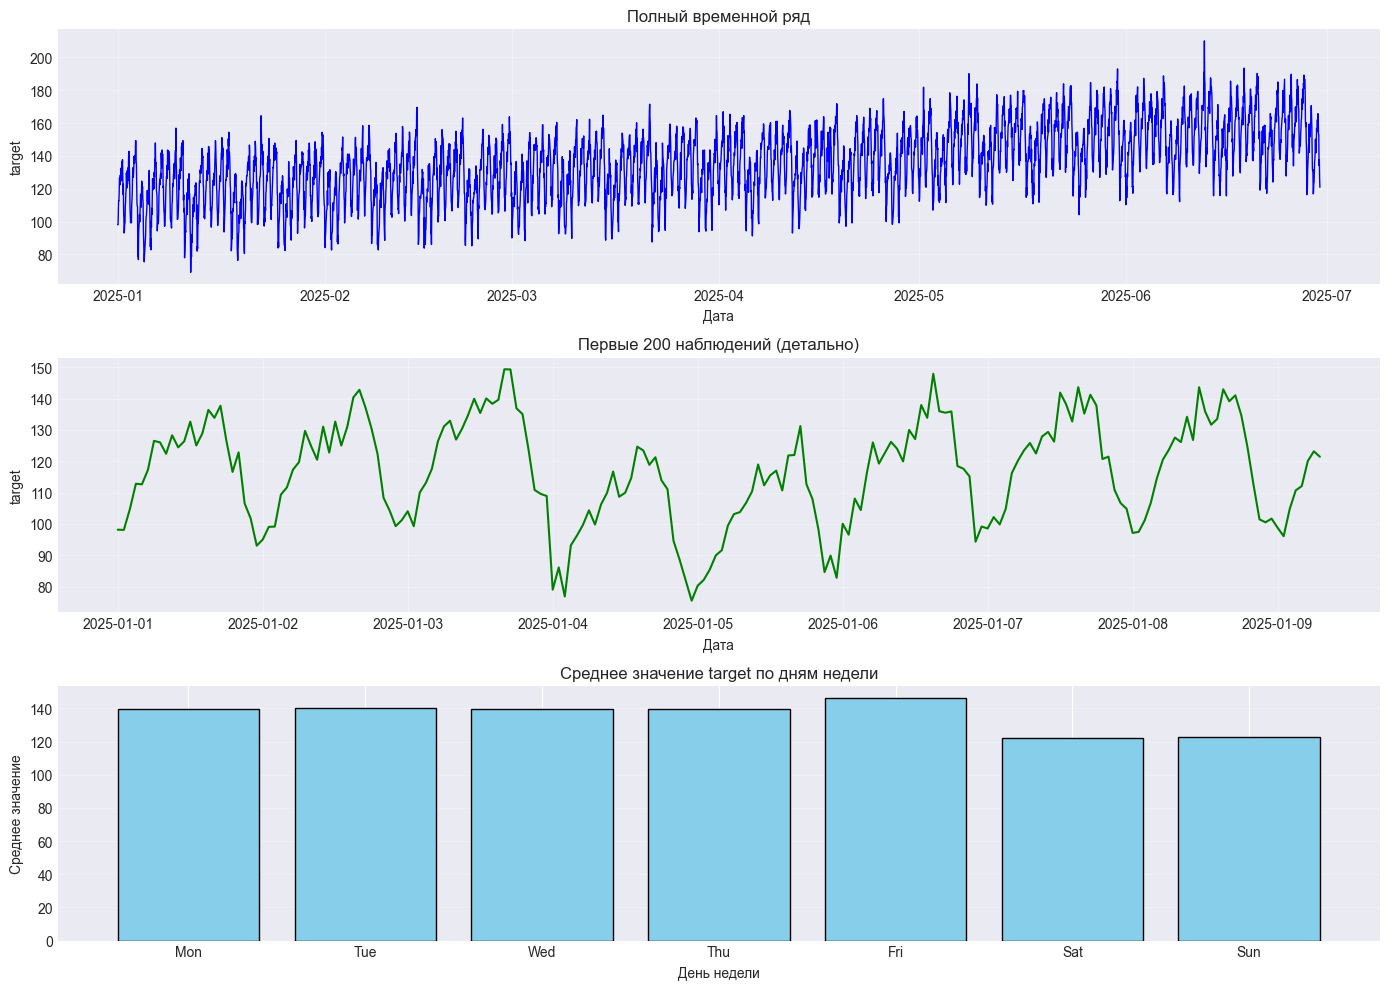

Train: 3024 записей (2025-01-01 00:00:00 до 2025-05-06 23:00:00)
Validation: 648 записей (2025-05-07 00:00:00 до 2025-06-02 23:00:00)
Test: 648 записей (2025-06-03 00:00:00 до 2025-06-29 23:00:00)


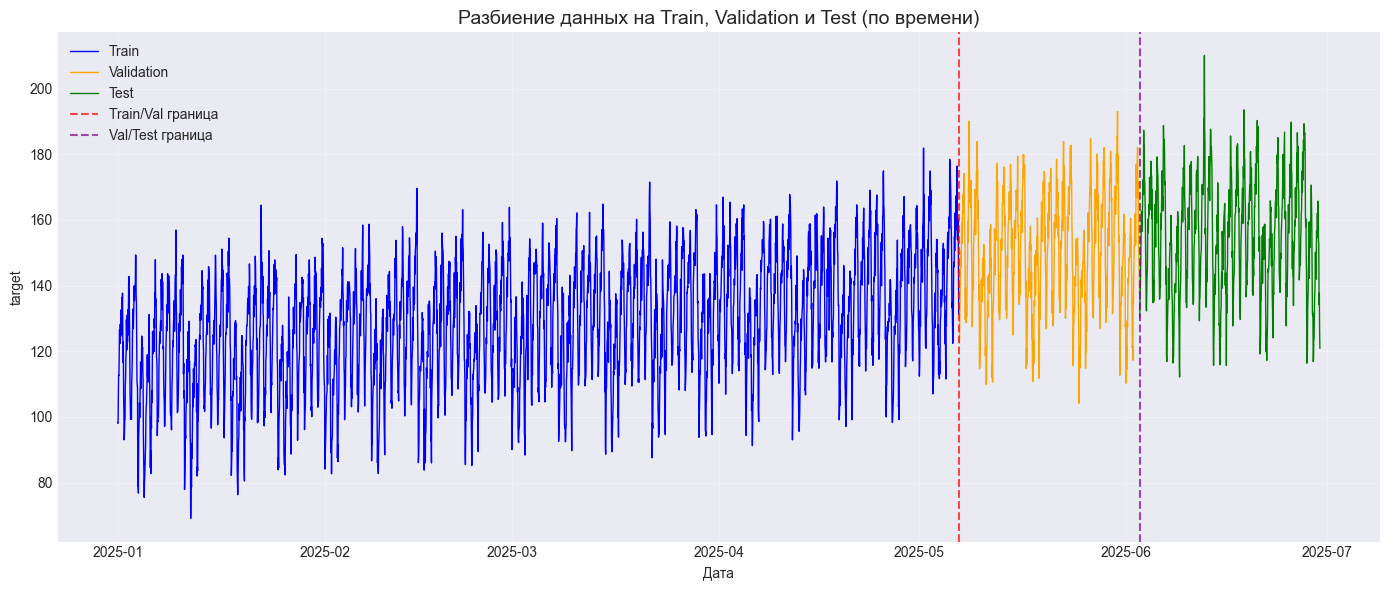

Средние значения в scaler (обучен на train): [128.1941369  128.09283399 127.94021825]
Средние значения X_train (первые 3 признака): [ 0.00000000e+00 -1.12784561e-16  7.89491929e-16]
Среднее X_train после масштабирования: [ 0.00000000e+00 -1.12784561e-16  7.89491929e-16]
Среднее X_val после масштабирования:   [1.20484574 1.19177946 1.17228955]
Среднее X_test после масштабирования:  [1.46418363 1.46109721 1.45595447]
B1: Naive Baseline (last value)
Validation MAE: 6.4448
Validation RMSE: 8.2010
Validation MAPE: 4.40%

B2: Moving Average (window=7)
Validation MAE: 16.0505
Validation RMSE: 19.3056
Validation MAPE: 10.44%

B3: Ridge Regression
Validation MAE: 6.4204
Validation RMSE: 8.0129
Validation MAPE: 4.30%

Top 5 важных признаков:
          feature  coefficient
0           lag_1    16.233824
6           month     2.231170
3  rolling_mean_7    -2.119036
5       dayofweek    -1.798148
4   rolling_std_7    -1.692102
Train batches: 95
Val batches: 20
Test batches: 20
R1: GRU Model Trainin

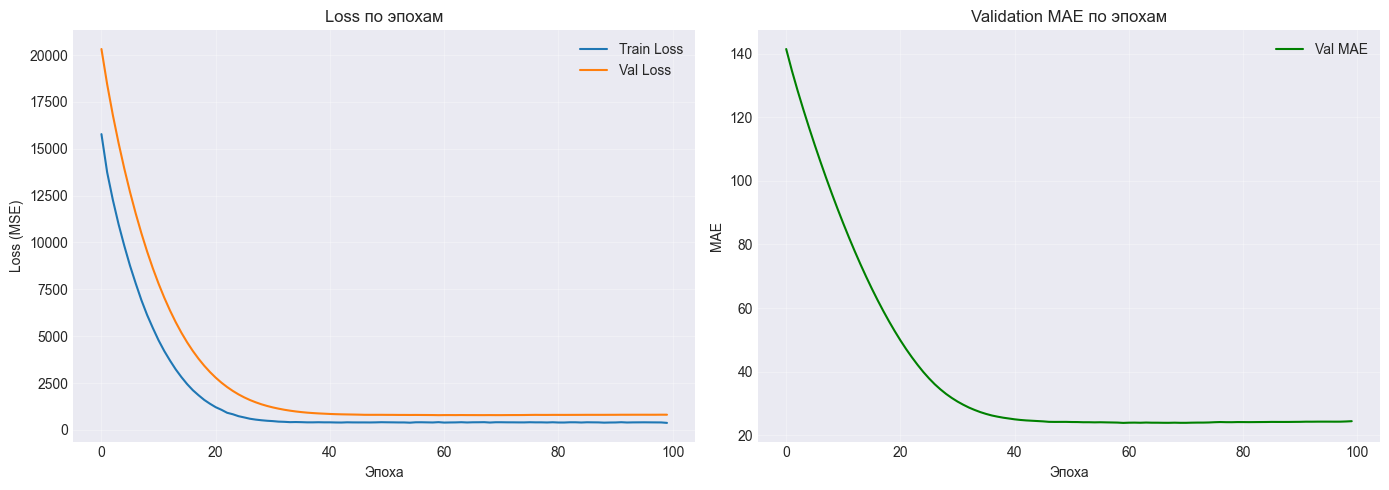

Сравнение моделей на валидационных данных:
          Model       MAE      RMSE  MAPE (%)
     B3 (Ridge)  6.420396  8.012930  4.297193
B1 (Naive Last)  6.444815  8.201023  4.397922
B2 (Moving Avg) 16.050510 19.305568 10.443998
       R1 (GRU) 24.437452 28.453710 15.384683


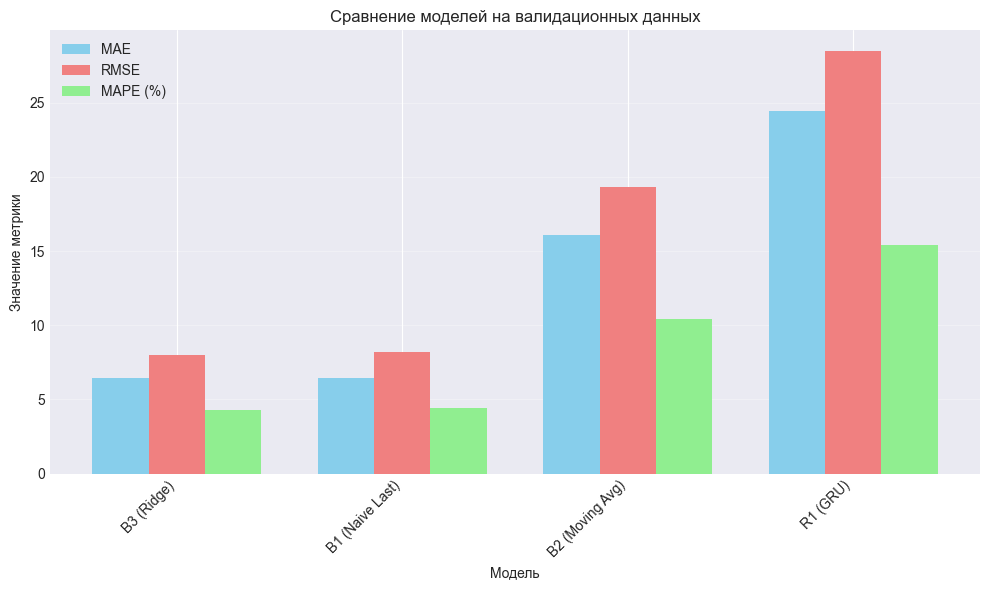

Финальное тестирование лучшей модели (GRU)
Test MAE: 28.2452
Test RMSE: 32.2459
Test MAPE: 17.31%


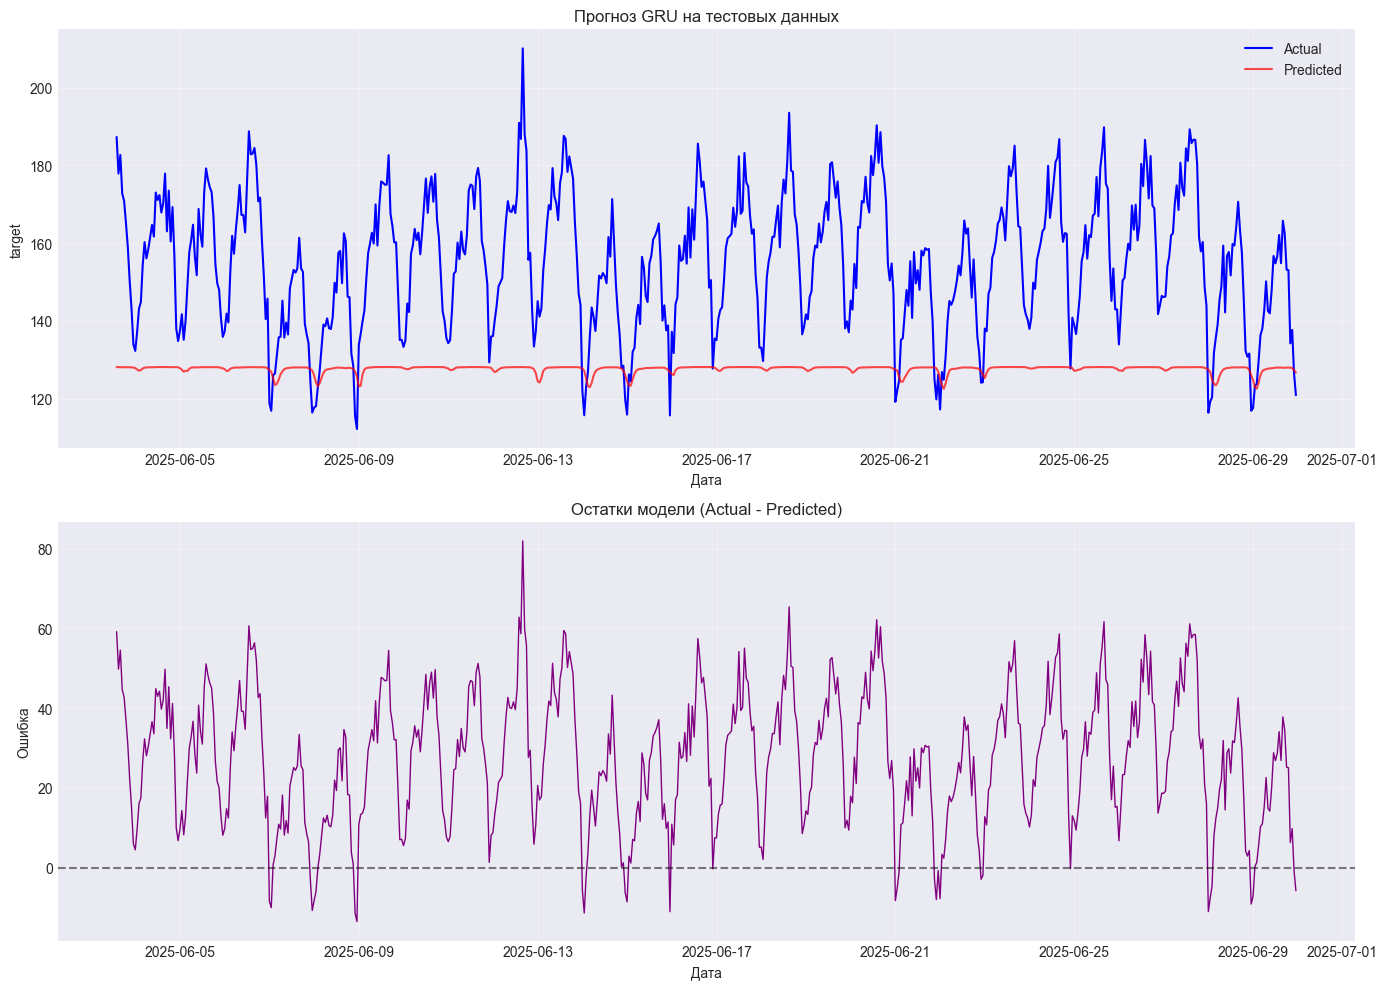

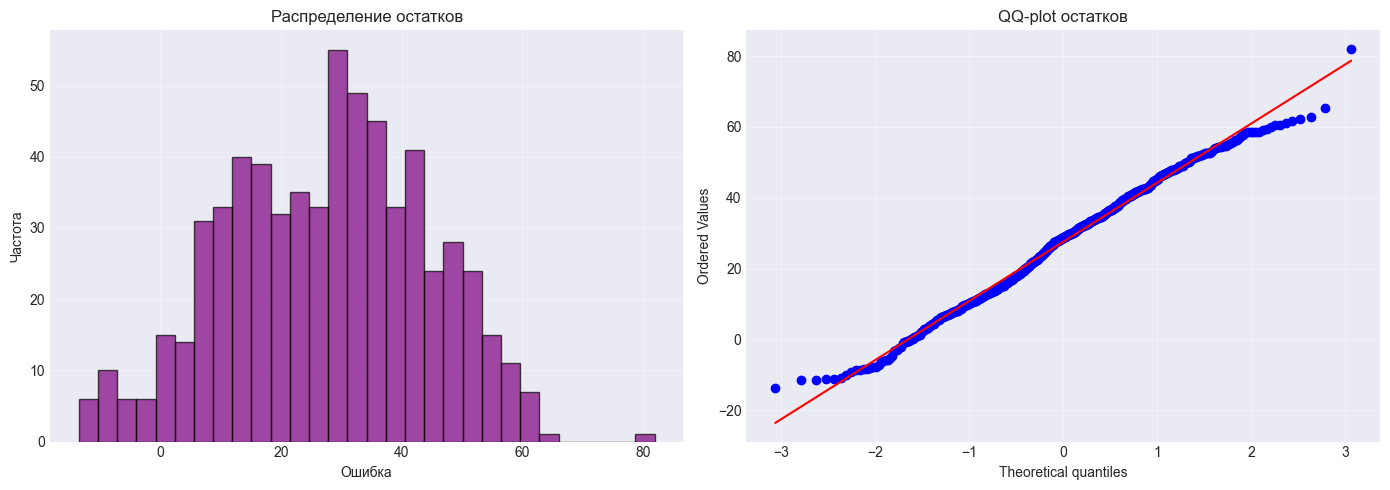

In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Настройки
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


ARTIFACTS_DIR = Path('./artifacts')
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


# Загрузка данных
df = pd.read_csv('data/S12-hw-dataset.csv')

# Преобразование date в datetime
df['date'] = pd.to_datetime(df['date'])

# Сортировка по времени
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер датасета: {len(df)} строк")
print(f"Диапазон дат: {df['date'].min()} до {df['date'].max()}")
print(f"\nПропуски в данных:")
print(df.isnull().sum())

# Базовый график ряда
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(df['date'], df['target'], linewidth=1)
ax[0].set_title('Временной ряд target')
ax[0].set_xlabel('Дата')
ax[0].set_ylabel('Значение')
ax[0].grid(True, alpha=0.3)

# Распределение значений
ax[1].hist(df['target'], bins=50, edgecolor='black', alpha=0.7)
ax[1].set_title('Распределение значений target')
ax[1].set_xlabel('Значение')
ax[1].set_ylabel('Частота')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Полный ряд
axes[0].plot(df['date'], df['target'], linewidth=1, color='blue')
axes[0].set_title('Полный временной ряд')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('target')
axes[0].grid(True, alpha=0.3)

# Первые 200 наблюдений для детального анализа
axes[1].plot(df['date'][:200], df['target'][:200], linewidth=1.5, color='green')
axes[1].set_title('Первые 200 наблюдений (детально)')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('target')
axes[1].grid(True, alpha=0.3)

# Статистика по дням недели
df['dayofweek'] = df['date'].dt.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_avg = df.groupby('dayofweek')['target'].mean()

axes[2].bar(day_names, weekly_avg, color='skyblue', edgecolor='black')
axes[2].set_title('Среднее значение target по дням недели')
axes[2].set_xlabel('День недели')
axes[2].set_ylabel('Среднее значение')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'series_detailed.png', dpi=150, bbox_inches='tight')
plt.show()


# Разбиение по времени: 70% train, 15% validation, 15% test
n = len(df)
train_size = int(0.7 * n)
val_size = int(0.15 * n)
test_size = n - train_size - val_size

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print(f"Train: {len(train_df)} записей ({train_df['date'].min()} до {train_df['date'].max()})")
print(f"Validation: {len(val_df)} записей ({val_df['date'].min()} до {val_df['date'].max()})")
print(f"Test: {len(test_df)} записей ({test_df['date'].min()} до {test_df['date'].max()})")


# Визуализация split
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'train': 'blue', 'validation': 'orange', 'test': 'green'}

ax.plot(train_df['date'], train_df['target'], label='Train', color=colors['train'], linewidth=1)
ax.plot(val_df['date'], val_df['target'], label='Validation', color=colors['validation'], linewidth=1)
ax.plot(test_df['date'], test_df['target'], label='Test', color=colors['test'], linewidth=1)

# Добавление вертикальных линий для границ split
split1_date = train_df['date'].iloc[-1]
split2_date = val_df['date'].iloc[-1]

ax.axvline(x=split1_date, color='red', linestyle='--', alpha=0.7, label='Train/Val граница')
ax.axvline(x=split2_date, color='purple', linestyle='--', alpha=0.7, label='Val/Test граница')

ax.set_title('Разбиение данных на Train, Validation и Test (по времени)', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'series_split.png', dpi=150, bbox_inches='tight')
plt.show()


# Random split некорректен, так как перемешивает данные, нарушая временную зависимость.
# Это приводит к утечке будущей информации в обучающую выборку, нереалистичной оценке качества модели,
# невозможности оценить способность модели к прогнозированию на новых данных.


def create_features(df, is_train=True, scaler=None):
    """Создание признаков без утечки будущей информации"""
    df = df.copy()

    # Лаговые признаки
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)

    # Скользящие статистики (используем только прошлые значения)
    df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7, min_periods=1).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window=7, min_periods=1).std()

    # Календарные признаки
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    # Заполнение пропусков
    df = df.fillna(method='bfill').fillna(method='ffill')

    # Признаки для модели
    feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                    'dayofweek', 'month', 'quarter']

    X = df[feature_cols].values
    y = df['target'].values

    # Масштабирование
    if is_train:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        return X_scaled, y, scaler
    else:
        X_scaled = scaler.transform(X)
        return X_scaled, y


# Создание признаков для train
X_train, y_train, scaler = create_features(train_df, is_train=True)
X_val, y_val = create_features(val_df, is_train=False, scaler=scaler)
X_test, y_test = create_features(test_df, is_train=False, scaler=scaler)

print("Средние значения в scaler (обучен на train):", scaler.mean_[:3])
print("Средние значения X_train (первые 3 признака):", X_train.mean(axis=0)[:3])
# Проверяем, что валидация не переобучала scaler
assert not hasattr(scaler, 'mean_') or scaler.mean_ is not None, "Scaler не обучен"

print(f"Среднее X_train после масштабирования: {X_train.mean(axis=0)[:3]}")
print(f"Среднее X_val после масштабирования:   {X_val.mean(axis=0)[:3]}")
print(f"Среднее X_test после масштабирования:  {X_test.mean(axis=0)[:3]}")


def evaluate_model(y_true, y_pred, prefix=""):
    """Расчет метрик качества"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        f'{prefix}mae': mae,
        f'{prefix}rmse': rmse,
        f'{prefix}mape': mape
    }


print("B1: Naive Baseline (last value)")
y_val_naive = np.roll(y_val, 1)
y_val_naive[0] = y_train[-1]  # Используем последнее значение из train
metrics_b1 = evaluate_model(y_val, y_val_naive, "val_")

print(f"Validation MAE: {metrics_b1['val_mae']:.4f}")
print(f"Validation RMSE: {metrics_b1['val_rmse']:.4f}")
print(f"Validation MAPE: {metrics_b1['val_mape']:.2f}%")

print("\nB2: Moving Average (window=7)")
window_size = 7
y_val_ma = np.convolve(y_train[-window_size:], np.ones(window_size) / window_size, mode='valid')
# Для валидации: используем скользящее среднее прошлых значений
y_val_ma_pred = []
for i in range(len(y_val)):
    if i < window_size:
        # Для первых точек используем среднее train + предыдущие валидационные
        window = y_train[-(window_size - i):] if i > 0 else y_train[-window_size:]
        window = list(window) + y_val_ma_pred[:i]
    else:
        window = y_val_ma_pred[i - window_size:i]
    y_val_ma_pred.append(np.mean(window))

metrics_b2 = evaluate_model(y_val, np.array(y_val_ma_pred), "val_")
print(f"Validation MAE: {metrics_b2['val_mae']:.4f}")
print(f"Validation RMSE: {metrics_b2['val_rmse']:.4f}")
print(f"Validation MAPE: {metrics_b2['val_mape']:.2f}%")

print("\nB3: Ridge Regression")
ridge_model = Ridge(alpha=1.0, random_state=SEED)
ridge_model.fit(X_train, y_train)

y_val_ridge = ridge_model.predict(X_val)
metrics_b3 = evaluate_model(y_val, y_val_ridge, "val_")
print(f"Validation MAE: {metrics_b3['val_mae']:.4f}")
print(f"Validation RMSE: {metrics_b3['val_rmse']:.4f}")
print(f"Validation MAPE: {metrics_b3['val_mape']:.2f}%")

# Feature importance
feature_names = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                 'dayofweek', 'month', 'quarter']
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': ridge_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 5 важных признаков:")
print(feature_importance.head())


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size):
        self.X = X
        self.y = y
        self.window_size = window_size

    def __len__(self):
        return len(self.X) - self.window_size

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.window_size]
        y_target = self.y[idx + self.window_size]
        return torch.FloatTensor(x_seq), torch.FloatTensor([y_target])


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :])  # Берем последний выход
        out = self.fc(out)
        return out


def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_model_gru(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()

            predictions.extend(outputs.cpu().numpy())
            targets.extend(batch_y.cpu().numpy())

    return total_loss / len(dataloader), np.array(predictions), np.array(targets)


WINDOW_SIZE = 14
BATCH_SIZE = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
NUM_EPOCHS = 100

# Создание датасетов
train_dataset = TimeSeriesDataset(X_train, y_train, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val, y_val, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test, y_test, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


# Инициализация модели
input_size = X_train.shape[1]
model = GRUModel(input_size, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)


# Обучение GRU
print("R1: GRU Model Training")
train_losses = []
val_losses = []
val_maes = []
best_val_mae = float('inf')
best_model_state = None

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_pred, val_true = evaluate_model_gru(model, val_loader, criterion, device)

    # Расчет MAE для валидации
    val_mae = mean_absolute_error(val_true, val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)

    # Снижение learning rate
    scheduler.step(val_loss)

    # Сохранение лучшей модели
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model_state = model.state_dict().copy()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], "
              f"Train Loss: {train_loss:.6f}, "
              f"Val Loss: {val_loss:.6f}, "
              f"Val MAE: {val_mae:.4f}")

# Восстановление лучшей модели
model.load_state_dict(best_model_state)

# Оценка на валидации с лучшей моделью
val_loss, val_pred, val_true = evaluate_model_gru(model, val_loader, criterion, device)
metrics_r1 = evaluate_model(val_true.flatten(), val_pred.flatten(), "val_")

print(f"\nЛучшая модель - Validation MAE: {metrics_r1['val_mae']:.4f}")


# Кривые обучения GRU
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=1.5)
ax1.plot(val_losses, label='Val Loss', linewidth=1.5)
ax1.set_title('Loss по эпохам')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_maes, label='Val MAE', color='green', linewidth=1.5)
ax2.set_title('Validation MAE по эпохам')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Сравнение моделей на валидации
comparison_df = pd.DataFrame({
    'Model': ['B1 (Naive Last)', 'B2 (Moving Avg)', 'B3 (Ridge)', 'R1 (GRU)'],
    'MAE': [metrics_b1['val_mae'], metrics_b2['val_mae'], metrics_b3['val_mae'], metrics_r1['val_mae']],
    'RMSE': [metrics_b1['val_rmse'], metrics_b2['val_rmse'], metrics_b3['val_rmse'], metrics_r1['val_rmse']],
    'MAPE (%)': [metrics_b1['val_mape'], metrics_b2['val_mape'], metrics_b3['val_mape'], metrics_r1['val_mape']]
})

comparison_df = comparison_df.sort_values('MAE')
print("Сравнение моделей на валидационных данных:")
print(comparison_df.to_string(index=False))


# Визуализация сравнения моделей
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.25

bars1 = ax.bar(x - width, comparison_df['MAE'], width, label='MAE', color='skyblue')
bars2 = ax.bar(x, comparison_df['RMSE'], width, label='RMSE', color='lightcoral')
bars3 = ax.bar(x + width, comparison_df['MAPE (%)'], width, label='MAPE (%)', color='lightgreen')

ax.set_xlabel('Модель')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей на валидационных данных')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baselines_compare.png', dpi=150, bbox_inches='tight')
plt.show()


# Тестирование лучшей модели (GRU) на test данных
print("Финальное тестирование лучшей модели (GRU)")

# Оценка на test данных
test_loss, test_pred, test_true = evaluate_model_gru(model, test_loader, criterion, device)
test_metrics = evaluate_model(test_true.flatten(), test_pred.flatten(), "test_")

print(f"Test MAE: {test_metrics['test_mae']:.4f}")
print(f"Test RMSE: {test_metrics['test_rmse']:.4f}")
print(f"Test MAPE: {test_metrics['test_mape']:.2f}%")


# Визуализация прогноза на test данных
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Основной график
test_dates = test_df['date'].iloc[WINDOW_SIZE:].values
ax1.plot(test_dates, test_true.flatten(), label='Actual', color='blue', linewidth=1.5)
ax1.plot(test_dates, test_pred.flatten(), label='Predicted', color='red', linewidth=1.5, alpha=0.7)
ax1.set_title('Прогноз GRU на тестовых данных')
ax1.set_xlabel('Дата')
ax1.set_ylabel('target')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Остатки
residuals = test_true.flatten() - test_pred.flatten()
ax2.plot(test_dates, residuals, color='purple', linewidth=1)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Остатки модели (Actual - Predicted)')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Ошибка')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'best_forecast_test.png', dpi=150, bbox_inches='tight')
plt.show()


# Статистика ошибок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Распределение ошибок
ax1.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='purple')
ax1.set_title('Распределение остатков')
ax1.set_xlabel('Ошибка')
ax1.set_ylabel('Частота')
ax1.grid(True, alpha=0.3)

# QQ plot (нормальность распределения)
from scipy import stats

stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('QQ-plot остатков')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'residuals_best.png', dpi=150, bbox_inches='tight')
plt.show()


# Сохранение runs.csv
runs_data = {
    'experiment_id': ['B1', 'B2', 'B3', 'R1'],
    'task': ['forecasting'] * 4,
    'dataset': ['S12-hw-dataset.csv'] * 4,
    'seed': [SEED] * 4,
    'split_summary': [f"train:{train_size}, val:{val_size}, test:{test_size}"] * 4,
    'window_size': [None, 7, None, WINDOW_SIZE],
    'horizon': [1] * 4,
    'model_summary': ['Naive Last', 'Moving Average (7)', 'Ridge(alpha=1.0)', f'GRU({HIDDEN_SIZE},{NUM_LAYERS})'],
    'features_summary': ['target', 'target',
                         'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, dayofweek, month, quarter',
                         'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, dayofweek, month, quarter'],
    'scaler': [None, None, 'StandardScaler', 'StandardScaler'],
    'optimizer': [None, None, None, 'Adam'],
    'lr': [None, None, None, LEARNING_RATE],
    'epochs_trained': [None, None, None, NUM_EPOCHS],
    'best_val_mae': [metrics_b1['val_mae'], metrics_b2['val_mae'], metrics_b3['val_mae'], metrics_r1['val_mae']],
    'best_val_rmse': [metrics_b1['val_rmse'], metrics_b2['val_rmse'], metrics_b3['val_rmse'], metrics_r1['val_rmse']],
    'best_val_mape': [metrics_b1['val_mape'], metrics_b2['val_mape'], metrics_b3['val_mape'], metrics_r1['val_mape']],
    'test_mae': [None, None, None, test_metrics['test_mae']],
    'test_rmse': [None, None, None, test_metrics['test_rmse']],
    'test_mape': [None, None, None, test_metrics['test_mape']],
    'notes': ['Baseline - last value', 'Baseline - moving average', 'Linear model with features', 'Best model - GRU']
}

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv(ARTIFACTS_DIR / 'runs.csv', index=False)


# Сохранение лучшей GRU модели
torch.save(best_model_state, ARTIFACTS_DIR / 'best_gru.pt')

# Сохранение конфигурации
import json

config = {
    'model_type': 'GRU',
    'input_size': input_size,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'seed': SEED,
    'device': str(device),
    'features': feature_names,
    'scaler_params': {
        'mean': scaler.mean_.tolist(),
        'scale': scaler.scale_.tolist()
    },
    'best_val_mae': metrics_r1['val_mae'],
    'test_mae': test_metrics['test_mae']
}

with open(ARTIFACTS_DIR / 'best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)
